In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math


In [2]:
Gfermi = 1.166379e-5
m_e = 0.0005109989461
m_mu = 0.1056583745
m_tau = 1.77686
m_piplus = 0.13957039
m_pizero = 0.1349768

vev = 246.22 # GeV

def Gpi(x, mpi):
    answer = (2.*x/9.) + (11.*mpi*mpi/9.)
    return answer

def width_ll(th, mS, ml):
    if mS > (2*ml):
        return th*th*ml*ml*mS*(math.sqrt( 1 - (4.*ml*ml/(mS*mS)) )**3)/(8.*math.pi*vev*vev) # matches TN
    else: 
        return 0.
def width_ee(th, mS):
    return width_ll(th, mS, m_e)
def width_mm(th, mS):
    return width_ll(th, mS, m_mu)


def width_pp(th, mS, mpi):
    if mS > (2.*mpi):
        return th*th*3*abs(Gpi(mS*mS,mpi))**2*math.sqrt( 1 - (4.*mpi*mpi/(mS*mS)))/(32.*math.pi*vev*vev*mS) # matches TN
    else: 
        return 0.
def width_pppm(th, mS):
    return 2*width_pp(th, mS, m_piplus)
def width_p0p0(th, mS):
    return width_pp(th, mS, m_pizero)

widths = {r'$e^+e^-$' : width_ee,
          r'$\mu^+\mu^-$' : width_mm,
          r'$\pi^0 \pi^0$' : width_p0p0,
          r'$\pi^+\pi^-$' : width_pppm}

def total_width(th, mS):
    return sum([widths[channel](th, mS) for channel in widths])

def br(channel,th, mS):
    total = total_width(th, mS)
    return widths[channel](th, mS)/total



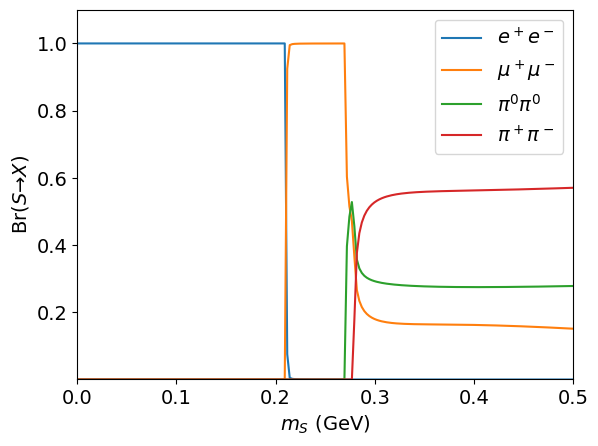

In [8]:
mSlist = np.linspace(0.00125,0.5,200)
plt.rcParams['font.size'] = 14
#for channel in all_brs_massScan:
#    plt.plot(mSlist, all_brs_massScan[channel], label=channel)
for channel in widths:
    this_br = [br(channel, 1., mS) for mS in mSlist]
    plt.plot(mSlist, this_br, label=channel)
#plt.yscale('log')
plt.xlim([0,0.5])
plt.ylim([3e-4,1.1])
plt.xlabel('$m_S$ (GeV)')
plt.ylabel('Br($S \u2192 X$)')
plt.legend()
plt.savefig('hps_br.pdf',bbox_inches = 'tight', dpi=300)
plt.show()